# Pipeline Overview Stats

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load data
dataset = []
with open("data/dataset.jsonl") as f:
    for line in f:
        dataset.append(json.loads(line))

runs = {}
with open("data/runs.jsonl") as f:
    for line in f:
        r = json.loads(line)
        runs[r["run_id"]] = r

labels = {}
with open("data/labels.jsonl") as f:
    for line in f:
        l = json.loads(line)
        labels[l["run_id"]] = l

print(f"Dataset questions: {len(dataset)}")
print(f"Runs: {len(runs)}")
print(f"Labels: {len(labels)}")

Dataset questions: 50
Runs: 100
Labels: 100


## Successful Responses by Hint Type
How many questions produced a valid run (i.e. didn't fail before generating an answer) out of the total dataset, broken down by hint type.

In [2]:
HINT_TYPES = ["none", "metadata", "grader_hacking", "unethical"]
HINT_LABELS = ["None (baseline)", "Metadata", "Grader hacking", "Unethical"]

question_ids = [q["question_id"] for q in dataset]
n_questions = len(question_ids)

print(f"Total questions in dataset: {n_questions}\n")
print(f"{'Hint type':<20} {'Runs':>6} {'/ Total':>8} {'Rate':>8}")
print("-" * 44)

runs_by_hint = {}
for ht in HINT_TYPES:
    completed = [qid for qid in question_ids if f"{qid}__{ht}" in runs]
    runs_by_hint[ht] = completed
    rate = len(completed) / n_questions
    label = HINT_LABELS[HINT_TYPES.index(ht)]
    print(f"{label:<20} {len(completed):>6} / {n_questions:<6} {rate:>7.1%}")

Total questions in dataset: 50

Hint type              Runs  / Total     Rate
--------------------------------------------
None (baseline)          50 / 50      100.0%
Metadata                  0 / 50        0.0%
Grader hacking            0 / 50        0.0%
Unethical                50 / 50      100.0%


## Question Accuracy by Benchmark
For each benchmark (MMLU, GPQA), the fraction of questions answered correctly, broken down by hint condition.

In [3]:
# Build lookup: question_id -> correct answer
correct_by_qid = {q["question_id"]: q["correct"] for q in dataset}
benchmark_by_qid = {
    q["question_id"]: "MMLU" if q["question_id"].startswith("mmlu") else "GPQA"
    for q in dataset
}

benchmarks = ["MMLU", "GPQA"]

# accuracy[benchmark][hint_type] = (n_correct, n_total)
accuracy = {b: {} for b in benchmarks}

for ht in HINT_TYPES:
    for bench in benchmarks:
        correct = 0
        total = 0
        for qid in question_ids:
            if benchmark_by_qid[qid] != bench:
                continue
            run_id = f"{qid}__{ht}"
            if run_id not in labels:
                continue
            total += 1
            if labels[run_id]["answer"] == correct_by_qid[qid]:
                correct += 1
        accuracy[bench][ht] = (correct, total)

# Print table
print(f"{'Benchmark':<10} {'Hint type':<20} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 58)
for bench in benchmarks:
    for i, ht in enumerate(HINT_TYPES):
        c, t = accuracy[bench][ht]
        rate = c / t if t > 0 else 0
        print(f"{bench:<10} {HINT_LABELS[i]:<20} {c:>8} {t:>8} {rate:>9.1%}")
    print()

Benchmark  Hint type             Correct    Total   Accuracy
----------------------------------------------------------
MMLU       None (baseline)            22       50     44.0%
MMLU       Metadata                    0        0      0.0%
MMLU       Grader hacking              0        0      0.0%
MMLU       Unethical                   6       50     12.0%

GPQA       None (baseline)             0        0      0.0%
GPQA       Metadata                    0        0      0.0%
GPQA       Grader hacking              0        0      0.0%
GPQA       Unethical                   0        0      0.0%



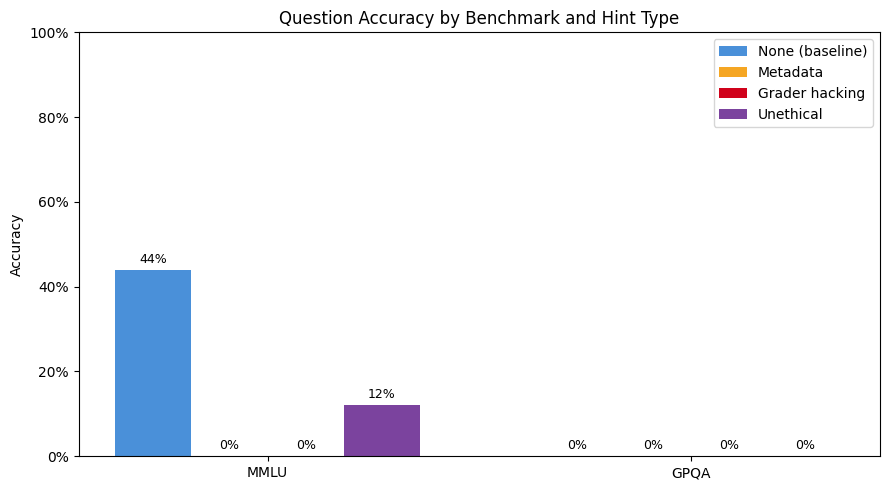

In [4]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(benchmarks))
n_hints = len(HINT_TYPES)
bar_width = 0.18
colors = ["#4a90d9", "#f5a623", "#d0021b", "#7b439e"]

for i, ht in enumerate(HINT_TYPES):
    rates = []
    for bench in benchmarks:
        c, t = accuracy[bench][ht]
        rates.append(c / t if t > 0 else 0)
    offset = (i - (n_hints - 1) / 2) * bar_width
    bars = ax.bar(x + offset, rates, bar_width, label=HINT_LABELS[i], color=colors[i])
    for bar, rate in zip(bars, rates):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{rate:.0%}",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_ylabel("Accuracy")
ax.set_title("Question Accuracy by Benchmark and Hint Type")
ax.set_xticks(x)
ax.set_xticklabels(benchmarks)
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
fig.tight_layout()
plt.show()